<a href="https://colab.research.google.com/github/sebastianvettel1212/Practical-Statistics-for-Data-Scientist-Books/blob/main/PracticalStatisticsChapter6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 6 — Statistical Machine Learning

**Buku:** *Practical Statistics for Data Scientists* — Peter Bruce, Andrew Bruce & Peter Gedeck (O'Reilly)

Notebook ini berisi reproduksi kode, ringkasan, dan penjelasan teori **Bab 6** dalam Bahasa Indonesia.

## Daftar Isi
0. Persiapan
1. K-Nearest Neighbors (KNN)
2. Model Pohon (*Tree Models*)
3. Bagging dan Random Forest
4. Boosting
5. Ringkasan Bab

---

## Pengantar

Kemajuan statistik terkini banyak berkaitan dengan **machine learning** yang **berbasis data**, bukan berbasis model teoretis. Berbeda dengan regresi linier dan logistik yang mengandalkan **model terstruktur** (mis. asumsi linearitas), metode di bab ini **bersifat non-parametrik / berbasis algoritma**: mereka **belajar langsung dari data** tanpa bentuk fungsi yang ditetapkan sebelumnya.

Bab ini memperkenalkan dua keluarga metode:
1. **K-Nearest Neighbors (KNN)**: klasifikasi berdasarkan kemiripan dengan rekaman terdekat.
2. **Metode ensemble berbasis pohon**: **pohon keputusan**, **bagging/random forest**, dan **boosting**. Ensemble menggabungkan banyak model sederhana menjadi satu model yang jauh lebih kuat.

> **Perbandingan istilah statistika vs machine learning.** Statistisi cenderung menekankan **inferensi** (memahami hubungan, ketidakpastian, signifikansi), sedangkan ML menekankan **prediksi** (akurasi pada data baru). Metode di bab ini lebih dekat ke ML: **akurasi prediksi** adalah tujuan utama dan model sering sulit ditafsirkan (*black box*).

## 0. Persiapan

In [2]:
import math
import os
import random
from pathlib import Path
from collections import defaultdict
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
import warnings

from sklearn import preprocessing
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [3]:
# Lokasi dataset: folder lokal 'data/' atau, bila tidak ada, langsung dari GitHub repo resmi buku
DATA_DIR = Path('data')
RAW_URL = ('https://raw.githubusercontent.com/gedeck/'
           'practical-statistics-for-data-scientists/master/data/')

def path_data(nama_file):
    lokal = DATA_DIR / nama_file
    return lokal if lokal.exists() else RAW_URL + nama_file

LOAN200_CSV = path_data('loan200.csv')
LOAN3000_CSV = path_data('loan3000.csv')
LOAN_DATA_CSV = path_data('loan_data.csv.gz')

---
## 1. K-Nearest Neighbors (KNN)

Gagasan KNN sangat sederhana: untuk mengklasifikasi sebuah rekaman baru, **cari $K$ rekaman paling mirip** (tetangga terdekat) di data latih, lalu **ambil suara terbanyak** di antara mereka.

| Istilah | Penjelasan |
|---|---|
| **Neighbor** | Rekaman yang memiliki nilai prediktor mirip dengan rekaman lain |
| **Distance metric** | Ukuran yang menyatakan seberapa jauh dua rekaman |
| **Standardization** | Mengurangi mean dan membagi simpangan baku (juga disebut normalisasi); menghasilkan **z-score** |
| **z-score** | Nilai hasil standardisasi |
| **K** | Banyaknya tetangga yang dipertimbangkan |

### Algoritma
1. Untuk rekaman yang ingin diklasifikasi, cari $K$ rekaman latih yang **paling mirip** (jarak terdekat) pada nilai prediktor.
2. **Klasifikasi** = kelas **mayoritas** di antara $K$ tetangga (voting). Untuk probabilitas, gunakan proporsi tetangga tiap kelas.
3. Untuk **regresi**, rata-ratakan nilai hasil tetangga.

**Metrik jarak:**
- **Euclidean** (garis lurus): $d(x, u) = \sqrt{\sum_j (x_j - u_j)^2}$
- **Manhattan** (jarak blok kota): $d(x, u) = \sum_j |x_j - u_j|$

Manhattan lebih kokoh terhadap outlier pada dimensi tunggal; Euclidean lebih umum.

### Contoh kecil: memprediksi gagal bayar
Dengan hanya dua prediktor, `payment_inc_ratio` dan `dti`, kita klasifikasi pinjaman pertama pada `loan200` memakai $K = 20$ tetangga terdekat dari 200 pinjaman lainnya.

In [4]:
loan200 = pd.read_csv(LOAN200_CSV)

predictors = ['payment_inc_ratio', 'dti']
outcome = 'outcome'

newloan = loan200.loc[0:0, predictors]     # pinjaman yang ingin diprediksi
X = loan200.loc[1:, predictors]
y = loan200.loc[1:, outcome]

print('Pinjaman baru:')
print(newloan)

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)
print('\nKelas prediksi :', knn.predict(newloan)[0])
print('Probabilitas   :', dict(zip(knn.classes_, knn.predict_proba(newloan)[0])))

Pinjaman baru:
   payment_inc_ratio   dti
0                9.0  22.5

Kelas prediksi : paid off
Probabilitas   : {'default': np.float64(0.45), 'paid off': np.float64(0.55)}


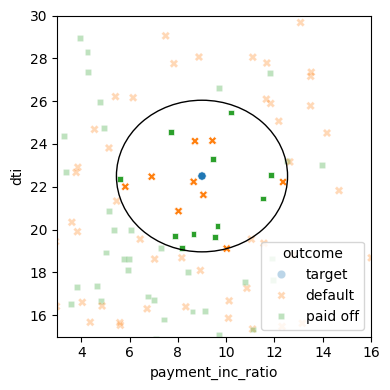

In [5]:
# Gambar 6-2: pinjaman baru, 20 tetangga terdekat, dan lingkaran jangkauan
nbrs = knn.kneighbors(newloan)
maxDistance = np.max(nbrs[0][0])

fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(x='payment_inc_ratio', y='dti', style='outcome',
                hue='outcome', data=loan200, alpha=0.3, ax=ax)
sns.scatterplot(x='payment_inc_ratio', y='dti', style='outcome',
                hue='outcome',
                data=pd.concat([loan200.loc[0:0, :], loan200.loc[nbrs[1][0] + 1, :]]),
                ax=ax, legend=False)
ellipse = Ellipse(xy=newloan.values[0],
                  width=2 * maxDistance, height=2 * maxDistance,
                  edgecolor='black', fc='None', lw=1)
ax.add_patch(ellipse)
ax.set_xlim(3, 16)
ax.set_ylim(15, 30)

plt.tight_layout()
plt.show()

**Interpretasi:** titik baru (bertanda tebal) dikelilingi 20 tetangga terdekatnya di dalam lingkaran. Proporsi kelas pada tetangga-tetangga inilah yang menjadi probabilitas prediksi: 11 dari 20 tetangga *paid off* (55%) dan 9 *default* (45%), sehingga pinjaman ini diprediksi **paid off**, tetapi dengan keyakinan yang rendah.

### Standardisasi (Normalisasi, Z-Score)
Pada KNN, prediktor dengan **skala besar mendominasi jarak**. Contoh: `revol_bal` (ribuan dolar) vs `payment_inc_ratio` (satuan). Solusinya **standardisasi** setiap prediktor sebelum menghitung jarak:

$$z = \frac{x - \bar{x}}{s}$$

In [6]:
loan_data = pd.read_csv(LOAN_DATA_CSV)
loan_data = loan_data.drop(columns=['Unnamed: 0', 'status'])
loan_data['outcome'] = pd.Categorical(loan_data['outcome'],
                                      categories=['paid off', 'default'],
                                      ordered=True)

predictors = ['payment_inc_ratio', 'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'

newloan = loan_data.loc[0:0, predictors]
print('Pinjaman baru:')
print(newloan)

X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

# TANPA standardisasi: tetangga terdekat didominasi oleh revol_bal (skala puluhan ribu)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)
nbrs = knn.kneighbors(newloan)
print('\n5 tetangga terdekat TANPA standardisasi:')
print(X.iloc[nbrs[1][0], :])

Pinjaman baru:
   payment_inc_ratio  dti  revol_bal  revol_util
0             2.3932  1.0       1687         9.4

5 tetangga terdekat TANPA standardisasi:
       payment_inc_ratio   dti  revol_bal  revol_util
35536            1.47212  1.46       1686        10.0
33651            3.38178  6.37       1688         8.4
25863            2.36303  1.39       1691         3.5
42953            1.28160  7.14       1684         3.9
43599            4.12244  8.98       1684         7.2


In [7]:
# DENGAN standardisasi
scaler = preprocessing.StandardScaler()
scaler.fit(X * 1.0)

X_std = scaler.transform(X * 1.0)
newloan_std = scaler.transform(newloan * 1.0)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_std, y)
nbrs = knn.kneighbors(newloan_std)
print('5 tetangga terdekat DENGAN standardisasi:')
print(X.iloc[nbrs[1][0], :])

5 tetangga terdekat DENGAN standardisasi:
       payment_inc_ratio   dti  revol_bal  revol_util
2080             2.61091  1.03       1218         9.7
1438             2.34343  0.51        278         9.9
30215            2.71200  1.34       1075         8.5
28542            2.39760  0.74       2917         7.4
44737            2.34309  1.37        488         7.2


**Interpretasi:** tanpa standardisasi, kelima tetangga memiliki **`revol_bal` hampir identik** dengan pinjaman baru (1.684-1.691 vs 1.687), sementara `dti` boleh berbeda jauh (1,39 sampai 8,98 vs 1,0); **jarak didominasi satu variabel berskala besar**. Setelah standardisasi, tetangga memiliki `payment_inc_ratio`, `dti`, dan `revol_util` yang **jauh lebih mirip** dengan pinjaman baru, sedangkan `revol_bal` kini bervariasi lebih lebar (278 sampai 2.917) karena tidak lagi mendominasi jarak. Kemiripan menjadi lebih seimbang di semua variabel.

### Memilih K
- **K kecil** (mis. 1): model **sangat fleksibel**, berisiko **overfitting** pada noise.
- **K besar**: model **lebih halus**, berisiko **underfitting** (mengabaikan struktur lokal).
- Praktik: pilih $K$ dengan **cross-validation**. Aturan umum: $K$ antara 1 dan 20; pada data besar $K$ bisa lebih besar. Bila ada banyak variabel/noise, $K$ perlu lebih besar.

Berikut demonstrasi pemilihan $K$ dengan cross-validation 5-fold pada `loan3000`.

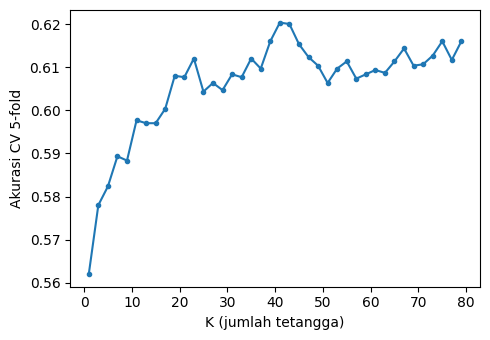

K terbaik: 41 dengan akurasi CV = 0.6203


In [8]:
# Tidak ada di buku: akurasi cross-validation sebagai fungsi K (loan3000, prediktor distandardisasi)
loan3000 = pd.read_csv(LOAN3000_CSV)
Xk = loan3000[['borrower_score', 'payment_inc_ratio']]
yk = loan3000['outcome']
Xk_std = preprocessing.StandardScaler().fit_transform(Xk)

ks = list(range(1, 80, 2))
acc = [cross_val_score(KNeighborsClassifier(n_neighbors=k), Xk_std, yk, cv=5).mean() for k in ks]

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(ks, acc, marker='.')
ax.set_xlabel('K (jumlah tetangga)'); ax.set_ylabel('Akurasi CV 5-fold')
plt.tight_layout(); plt.show()
print(f'K terbaik: {ks[int(np.argmax(acc))]} dengan akurasi CV = {max(acc):.4f}')

**Interpretasi:** akurasi rendah pada $K$ sangat kecil (≈ 0,56 pada $K=1$, model terlalu mengikuti noise), naik ke puncak pada $K$ menengah (≈ 0,62 pada $K=41$), lalu cenderung mendatar dan sedikit turun pada $K$ besar. Inilah *trade-off bias-variance*. Akurasi tertinggi yang hanya ≈ 62% mencerminkan sulitnya memprediksi gagal bayar dengan dua prediktor.

### KNN sebagai *Feature Engine*
KNN sering dipakai **bukan sebagai model akhir**, melainkan untuk **membuat fitur baru** bagi model lain: probabilitas hasil KNN (berbasis kemiripan lokal) menjadi variabel baru. Pada data pinjaman, **`borrower_score`** (skor peminjam) dihasilkan seperti itu: KNN dengan $K=20$ pada beberapa prediktor, lalu probabilitas *paid off* dipakai sebagai skor.

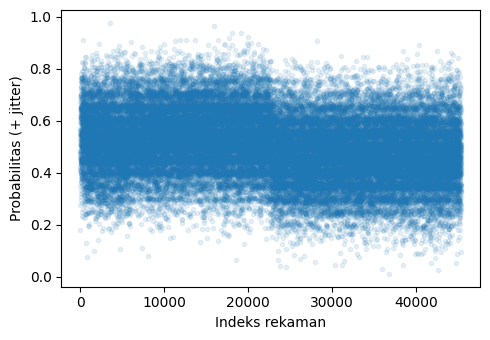

count    45342.000000
mean         0.501098
std          0.128736
min          0.000000
25%          0.400000
50%          0.500000
75%          0.600000
max          0.950000
Name: borrower_score, dtype: float64


In [9]:
loan_data = pd.read_csv(LOAN_DATA_CSV)
loan_data = loan_data.drop(columns=['Unnamed: 0', 'status'])
loan_data['outcome'] = pd.Categorical(loan_data['outcome'],
                                      categories=['paid off', 'default'],
                                      ordered=True)

predictors = ['dti', 'revol_bal', 'revol_util', 'open_acc', 'delinq_2yrs_zero', 'pub_rec_zero']
outcome = 'outcome'

X = loan_data[predictors]
y = loan_data[outcome]

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)

plt.figure(figsize=(5, 3.5))
plt.scatter(range(len(X)), [bs + random.gauss(0, 0.015) for bs in knn.predict_proba(X)[:, 0]],
            alpha=0.1, marker='.')
plt.xlabel('Indeks rekaman'); plt.ylabel('Probabilitas (+ jitter)')
plt.tight_layout(); plt.show()

loan_data['borrower_score'] = knn.predict_proba(X)[:, 0]
print(loan_data['borrower_score'].describe())

**Interpretasi:** dengan $K = 20$, probabilitas hanya dapat bernilai **kelipatan 0,05** (jumlah tetangga *paid off* dibagi 20), dari 0 hingga 0,95, dengan rata-rata ≈ 0,50. Skor ini merangkum 6 prediktor menjadi satu angka, yang kemudian dipakai sebagai prediktor kuat di model lain.

> **Catatan.** Skor ini dihitung pada data latih yang sama (tetangga terdekat termasuk dirinya sendiri), sehingga cenderung **terlalu optimistis**; pada praktiknya sebaiknya dihitung dengan *out-of-fold* untuk menghindari kebocoran.

### Key Ideas
- KNN mengklasifikasi rekaman dengan **menetapkannya ke kelas yang sama dengan rekaman-rekaman paling mirip** di data latih.
- **Kemiripan** diukur dengan **jarak** (Euclidean/Manhattan), dan prediktor harus **distandardisasi**.
- **K** menentukan kompleksitas dan dipilih lewat **cross-validation**.
- KNN sering dipakai sebagai **tahap pertama** untuk membangun fitur bagi model lain.

---
## 2. Model Pohon (*Tree Models*)

**Model pohon** (juga disebut **CART**, *Classification and Regression Trees*, atau **decision tree**) adalah alat klasifikasi dan regresi yang kuat dan populer. Ia menghasilkan **aturan "jika-maka"** yang mudah ditafsirkan, dan menjadi dasar bagi **random forest** dan **boosting**.

| Istilah | Penjelasan |
|---|---|
| **Recursive partitioning** | Membagi data berulang kali ke subpartisi |
| **Split value** | Nilai prediktor yang membagi rekaman ke dua partisi |
| **Node** | Titik keputusan; pada akhir pohon disebut **leaf (daun)** |
| **Leaf** | Node akhir; berisi aturan klasifikasi |
| **Loss** | Kesalahan klasifikasi pada sebuah split |
| **Impurity** | Tingkat ketidakmurnian (campuran kelas) dalam sebuah partisi |
| **Pruning** | Memangkas cabang pohon agar tidak overfit |

### Contoh sederhana
Pohon sederhana dibangun pada `loan3000` dengan `borrower_score` dan `payment_inc_ratio`.

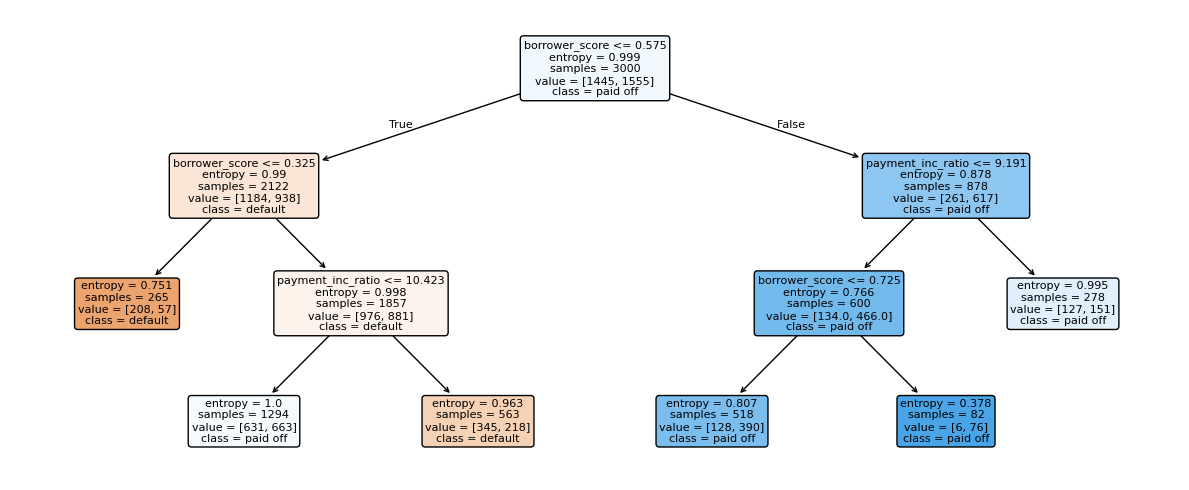

In [10]:
loan3000 = pd.read_csv(LOAN3000_CSV)

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(random_state=1, criterion='entropy',
                                   min_impurity_decrease=0.003)
loan_tree.fit(X, y)

fig, ax = plt.subplots(figsize=(12, 5))
plot_tree(loan_tree, feature_names=predictors, class_names=list(loan_tree.classes_),
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.tight_layout()
plt.show()

In [11]:
# Aturan pohon dalam bentuk teks (mudah dibaca dan diterapkan sebagai aturan bisnis)
print(export_text(loan_tree, feature_names=predictors))

|--- borrower_score <= 0.58
|   |--- borrower_score <= 0.33
|   |   |--- class: default
|   |--- borrower_score >  0.33
|   |   |--- payment_inc_ratio <= 10.42
|   |   |   |--- class: paid off
|   |   |--- payment_inc_ratio >  10.42
|   |   |   |--- class: default
|--- borrower_score >  0.58
|   |--- payment_inc_ratio <= 9.19
|   |   |--- borrower_score <= 0.72
|   |   |   |--- class: paid off
|   |   |--- borrower_score >  0.72
|   |   |   |--- class: paid off
|   |--- payment_inc_ratio >  9.19
|   |   |--- class: paid off



**Interpretasi:** aturan dibaca dari akar ke daun. Misalnya: *jika* `borrower_score` ≤ ambang kecil → prediksi **default**; *jika* tinggi, periksa `payment_inc_ratio` terhadap ambang berikutnya, dst. Keunggulan pohon: **aturan eksplisit** yang bisa dibaca non-teknis dan diterapkan tanpa komputer.

### Algoritma Partisi Rekursif
Algoritma pohon mencari **split terbaik** secara serakah (*greedy*):
1. Untuk setiap prediktor $X_j$ dan setiap nilai split $s_j$, bagi data menjadi dua partisi: $X_j < s_j$ dan $X_j \ge s_j$.
2. Ukur **homogenitas kelas** (kemurnian) di tiap partisi.
3. Pilih split yang menghasilkan **partisi paling homogen** (impurity berkurang paling banyak).
4. **Ulangi** secara rekursif di setiap partisi sampai kriteria berhenti terpenuhi.

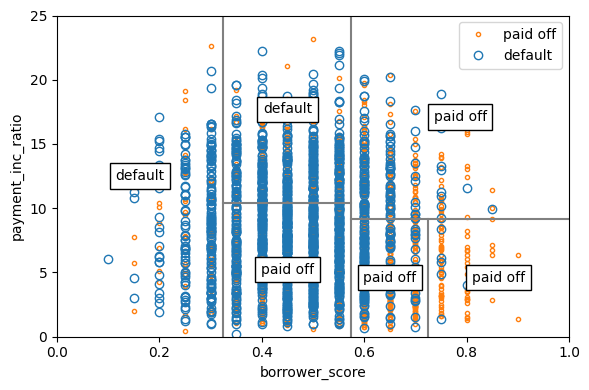

In [12]:
# Gambar 6-3: partisi rekursif pada ruang (borrower_score, payment_inc_ratio)
fig, ax = plt.subplots(figsize=(6, 4))

loan3000.loc[loan3000.outcome == 'paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.',
    markerfacecolor='none', markeredgecolor='C1', ax=ax)
loan3000.loc[loan3000.outcome == 'default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o',
    markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default'])
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score')
ax.set_ylabel('payment_inc_ratio')

# split-split dari pohon pada buku
x0 = 0.575
x1a = 0.325; y1b = 9.191
y2a = 10.423; x2b = 0.725
ax.plot((x0, x0), (0, 25), color='grey')
ax.plot((x1a, x1a), (0, 25), color='grey')
ax.plot((x0, 1), (y1b, y1b), color='grey')
ax.plot((x1a, x0), (y2a, y2a), color='grey')
ax.plot((x2b, x2b), (0, y1b), color='grey')

labels = [('default', (x1a / 2, 25 / 2)),
          ('default', ((x0 + x1a) / 2, (25 + y2a) / 2)),
          ('paid off', ((x0 + x1a) / 2, y2a / 2)),
          ('paid off', ((1 + x0) / 2, (y1b + 25) / 2)),
          ('paid off', ((1 + x2b) / 2, (y1b + 0) / 2)),
          ('paid off', ((x0 + x2b) / 2, (y1b + 0) / 2))]
for label, (x, y_) in labels:
    ax.text(x, y_, label, bbox={'facecolor': 'white'},
            verticalalignment='center', horizontalalignment='center')

plt.tight_layout()
plt.show()

**Interpretasi:** garis-garis abu-abu adalah **split sumbu-sejajar** yang membagi ruang prediktor menjadi **persegi panjang** (partisi). Tiap persegi panjang diberi satu label kelas (mayoritas). Inilah mengapa batas keputusan pohon berbentuk **tangga**.

### Mengukur Homogenitas atau Impurity
Dua ukuran ketidakmurnian yang umum, dengan $p$ = proporsi kelas 1 pada partisi:

$$\text{Gini}: \; I(A) = p(1 - p) \qquad\qquad \text{Entropi}: \; I(A) = -p\log_2 p - (1-p)\log_2(1-p)$$

Keduanya bernilai **0 bila partisi murni** ($p=0$ atau $p=1$) dan **maksimum bila campuran 50/50**. Entropi dipakai pada **information gain**. **Akurasi (kesalahan klasifikasi)** juga bisa dipakai, tetapi **kurang sensitif** terhadap perubahan kecil.

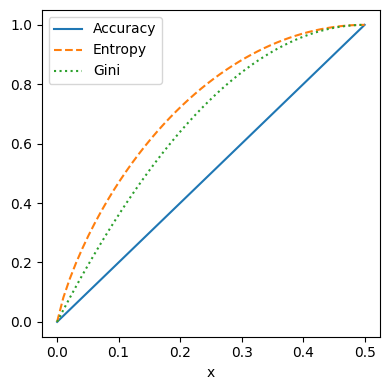

In [13]:
# Gambar 6-6: perbandingan ukuran impurity (Akurasi, Gini, Entropi)
def entropyFunction(x):
    if x == 0: return 0
    return -x * math.log(x, 2) - (1 - x) * math.log(1 - x, 2)

def giniFunction(x):
    return x * (1 - x)

x = np.linspace(0, 0.5, 50)
impure = pd.DataFrame({
    'x': x,
    'Accuracy': 2 * x,
    'Gini': [giniFunction(xi) / giniFunction(.5) for xi in x],
    'Entropy': [entropyFunction(xi) for xi in x],
})

fig, ax = plt.subplots(figsize=(4, 4))
impure.plot(x='x', y='Accuracy', ax=ax, linestyle='solid')
impure.plot(x='x', y='Entropy', ax=ax, linestyle='--')
impure.plot(x='x', y='Gini', ax=ax, linestyle=':')

plt.tight_layout()
plt.show()

In [14]:
# Hitung impurity satu split secara manual: bandingkan impurity sebelum dan sesudah split borrower_score <= 0.575
def gini(labels):
    p = np.mean(labels == 'default')
    return 2 * p * (1 - p)               # bentuk Gini sklearn: 1 - sum(p_k^2) = 2p(1-p) untuk 2 kelas

split = 0.575
kiri = loan3000.loc[loan3000.borrower_score <= split, 'outcome']
kanan = loan3000.loc[loan3000.borrower_score > split, 'outcome']
sebelum = gini(loan3000['outcome'])
sesudah = (len(kiri) * gini(kiri) + len(kanan) * gini(kanan)) / len(loan3000)
print(f'Gini sebelum split : {sebelum:.4f}')
print(f'Gini sesudah split : {sesudah:.4f}  (rata-rata berbobot)')
print(f'Penurunan impurity : {sebelum - sesudah:.4f}')

Gini sebelum split : 0.4993
Gini sesudah split : 0.4712  (rata-rata berbobot)
Penurunan impurity : 0.0281


**Interpretasi:** pada 2 kelas, ketiga kurva sama-sama 0 di ujung (murni) dan puncak di 0,5 (paling campur). Entropi dan Gini **lebih melengkung** daripada akurasi, sehingga lebih peka. Contoh manual menunjukkan bahwa split yang baik **menurunkan impurity berbobot**, kriteria yang dioptimalkan algoritma.

### Menghentikan Pertumbuhan Pohon
Bila pohon dibiarkan tumbuh penuh, ia akan **menghafal data latih** (overfit). Strategi:
- **Aturan berhenti**: batas kedalaman (`max_depth`), minimum rekaman per partisi (`min_samples_split`/`min_samples_leaf`), atau penurunan impurity minimum (`min_impurity_decrease`).
- **Pruning (pemangkasan)**: tumbuhkan pohon penuh, lalu pangkas cabang yang tidak meningkatkan kinerja validasi (di scikit-learn: `ccp_alpha`, *cost-complexity pruning*).

Berikut dampak kedalaman pohon terhadap akurasi latih dan validasi.

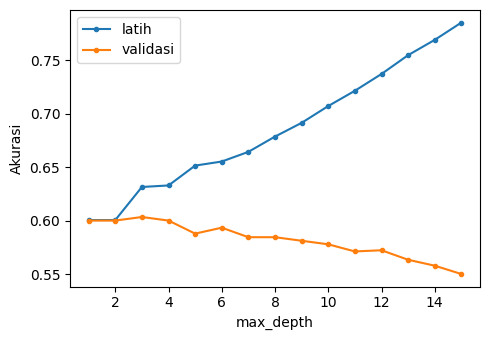

 max_depth  latih  validasi
         1  0.600     0.600
         2  0.600     0.600
         3  0.631     0.603
         4  0.633     0.600
         5  0.651     0.588
         6  0.655     0.593
         7  0.664     0.584
         8  0.679     0.584
         9  0.691     0.581
        10  0.707     0.578
        11  0.721     0.571
        12  0.737     0.572
        13  0.755     0.563
        14  0.769     0.558
        15  0.785     0.550


In [15]:
# Tidak ada di buku: overfitting pada pohon - akurasi latih vs validasi terhadap max_depth
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)
rows = []
for d in range(1, 16):
    t = DecisionTreeClassifier(max_depth=d, random_state=1).fit(Xtr, ytr)
    rows.append({'max_depth': d, 'latih': t.score(Xtr, ytr), 'validasi': t.score(Xva, yva)})
depth_df = pd.DataFrame(rows)

ax = depth_df.plot(x='max_depth', y=['latih', 'validasi'], marker='.', figsize=(5, 3.5))
ax.set_ylabel('Akurasi')
plt.tight_layout(); plt.show()
print(depth_df.round(3).to_string(index=False))

**Interpretasi:** akurasi **latih** terus naik (dari 0,60 pada kedalaman 1 menjadi 0,785 pada kedalaman 15), sedangkan akurasi **validasi** mencapai puncak sekitar **0,603 pada kedalaman 3** lalu **turun** hingga 0,55. Selisih yang melebar menandakan **overfitting**; kedalaman optimal dipilih dari kurva validasi, bukan kurva latih.

### Memprediksi Nilai Kontinu
Pohon juga dapat memprediksi **nilai numerik** (pohon **regresi**): prediksi pada daun = **rata-rata** hasil rekaman di daun itu. Ukuran impurity diganti **variansi/MSE** dalam partisi.

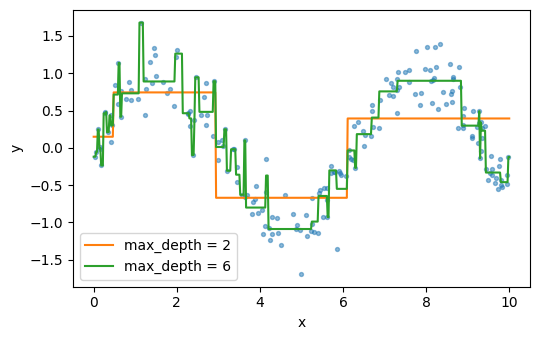

In [16]:
# Tidak ada di buku: pohon regresi sederhana pada data nonlinier
rng = np.random.default_rng(0)
xr = np.sort(rng.uniform(0, 10, 200))
yr = np.sin(xr) + rng.normal(0, 0.25, 200)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.scatter(xr, yr, s=8, alpha=0.5)
xx = np.linspace(0, 10, 500).reshape(-1, 1)
for d, warna in [(2, 'C1'), (6, 'C2')]:
    reg = DecisionTreeRegressor(max_depth=d, random_state=0).fit(xr.reshape(-1, 1), yr)
    ax.plot(xx, reg.predict(xx), color=warna, label=f'max_depth = {d}')
ax.legend(); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout(); plt.show()

**Interpretasi:** prediksi pohon regresi berupa **fungsi tangga** (konstan per partisi). Pohon dangkal terlalu kasar; pohon dalam mengikuti pola tetapi mulai mengikuti noise.

### Mempelajari Aturan dan Interpretasi
Kelebihan pohon: **mudah dijelaskan**, tidak butuh standardisasi, menangani **interaksi** dan **hubungan non-linear** secara alami, dan dapat bekerja dengan variabel campuran. Kekurangan: **tidak stabil** (perubahan kecil pada data dapat mengubah pohon drastis) dan **kurang akurat** dibanding ensemble. Itulah mengapa pohon tunggal jarang dipakai sendirian, melainkan **dikombinasikan** (random forest, boosting).

### Key Ideas
- Pohon menghasilkan **aturan** untuk memprediksi hasil: serangkaian pertanyaan "ya/tidak" tentang nilai prediktor.
- Aturan dihasilkan lewat **partisi rekursif**: tiap langkah mencari split yang **paling memisahkan** kelas.
- Pohon yang terlalu dalam **overfit**; dikendalikan dengan aturan berhenti atau **pruning** lewat validasi silang.
- Pohon dapat memprediksi **nilai kontinu** (rata-rata pada daun).

---
## 3. Bagging dan Random Forest

Gagasan **ensemble**: menggabungkan **banyak model** menjadi satu prediksi yang lebih baik, umumnya dengan **merata-ratakan** atau **voting**. Syaratnya, model-model itu **beragam** dan tidak terlalu berkorelasi.

| Istilah | Penjelasan |
|---|---|
| **Ensemble** | Membentuk prediksi dengan memakai **kumpulan model** |
| **Bagging** | Membuat banyak model dari **sampel bootstrap** data (**b**ootstrap **agg**regat**ing**) |
| **Random forest** | Bagging pada pohon keputusan **plus** pemilihan **subset acak prediktor** di tiap split |
| **Variable importance** | Ukuran **seberapa penting** sebuah prediktor bagi kinerja model |

### Bagging
Algoritma:
1. Misalkan ingin $M$ model, $n$ rekaman.
2. Tarik **sampel bootstrap** ukuran $n$ (dengan pengembalian) dari data.
3. Latih model pada sampel itu.
4. Ulangi $M$ kali; **rata-ratakan** prediksi (atau voting).

Bagging **menurunkan variansi** model tak stabil (seperti pohon) tanpa menaikkan bias secara berarti.

### Random Forest
Random forest = bagging pohon, ditambah **satu trik**: pada setiap split, hanya **subset acak** prediktor yang dipertimbangkan. Tujuannya **mengurangi korelasi antar pohon** sehingga ensemble lebih beragam. Hasilnya sering sangat akurat tanpa banyak penyetelan.

Hiperparameter utama: `n_estimators` (jumlah pohon), `max_features` (prediktor per split), `min_samples_leaf`, `max_depth`.

In [17]:
# Demonstrasi bagging manual: banyak pohon pada sampel bootstrap, lalu voting
loan3000 = pd.read_csv(LOAN3000_CSV)
predictors = ['borrower_score', 'payment_inc_ratio']
X = loan3000[predictors]
y = loan3000['outcome']
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.3, random_state=2, stratify=y)

rng = np.random.default_rng(1)
M = 100
votes = np.zeros((len(Xva), 2))
akurasi_pohon = []
for m in range(M):
    idx = rng.integers(0, len(Xtr), len(Xtr))                  # sampel bootstrap
    t = DecisionTreeClassifier(random_state=m).fit(Xtr.iloc[idx], ytr.iloc[idx])
    akurasi_pohon.append(t.score(Xva, yva))
    pred = t.predict(Xva)
    votes[:, 0] += (pred == 'default'); votes[:, 1] += (pred == 'paid off')

bagging_pred = np.where(votes[:, 0] >= votes[:, 1], 'default', 'paid off')
print(f'Akurasi rata-rata satu pohon penuh  : {np.mean(akurasi_pohon):.4f}')
print(f'Akurasi bagging ({M} pohon, voting)   : {np.mean(bagging_pred == yva):.4f}')

Akurasi rata-rata satu pohon penuh  : 0.5627
Akurasi bagging (100 pohon, voting)   : 0.5678


**Interpretasi:** voting 100 pohon yang masing-masing *overfit* memberi akurasi **sedikit lebih tinggi** (≈ 0,568) daripada rata-rata satu pohon penuh (≈ 0,563). Peningkatannya kecil karena sinyal pada dua prediktor ini memang lemah, tetapi arahnya sesuai teori: bagging menurunkan variansi.

### Contoh: prediksi default dengan random forest
Random forest dengan 500 pohon pada `borrower_score` dan `payment_inc_ratio`. Opsi `oob_score=True` menghitung **out-of-bag (OOB) estimate**: tiap pohon dievaluasi pada rekaman yang **tidak ikut** sampel bootstrap-nya (sekitar 37% rekaman), sehingga memberi estimasi galat **tanpa data uji terpisah**.

In [18]:
rf = RandomForestClassifier(n_estimators=500, random_state=1, oob_score=True)
rf.fit(X, y)
print('Skor OOB (akurasi):', round(rf.oob_score_, 4))
print('\nProbabilitas OOB (5 baris pertama):')
print(pd.DataFrame(rf.oob_decision_function_, columns=rf.classes_).head())

Skor OOB (akurasi): 0.5753

Probabilitas OOB (5 baris pertama):
    default  paid off
0  0.181319  0.818681
1  0.267045  0.732955
2  0.933333  0.066667
3  0.173077  0.826923
4  1.000000  0.000000


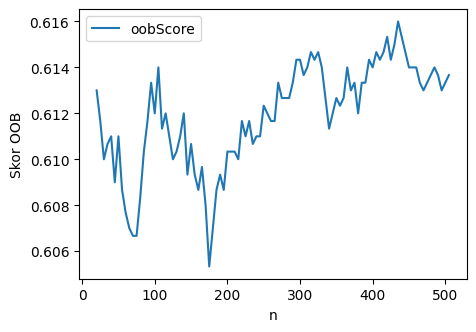

In [19]:
# Gambar 6-7: akurasi OOB sebagai fungsi jumlah pohon
n_estimator = list(range(20, 510, 5))
oobScores = []
for k in n_estimator:
    rf_k = RandomForestClassifier(n_estimators=k, criterion='entropy', max_depth=5,
                                  random_state=1, oob_score=True)
    rf_k.fit(X, y)
    oobScores.append(rf_k.oob_score_)

ax = pd.DataFrame({'n': n_estimator, 'oobScore': oobScores}).plot(x='n', y='oobScore', figsize=(5, 3.5))
ax.set_ylabel('Skor OOB')
plt.show()

**Interpretasi:** skor OOB bergerak dalam rentang sempit (≈ 0,605 sampai 0,616) dan cenderung **sedikit naik lalu stabil** setelah beberapa ratus pohon. Menambah pohon umumnya **tidak menyebabkan overfitting** pada random forest (hanya menambah waktu komputasi), sehingga aman memakai banyak pohon. Skor OOB pada model awal tanpa batas kedalaman (500 pohon) ≈ 0,575.

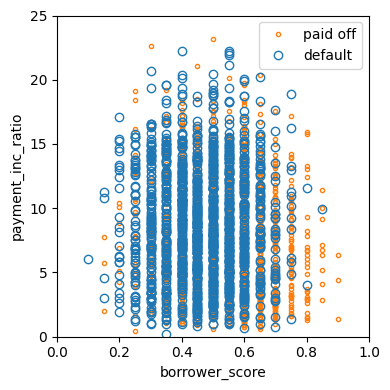

In [20]:
# Gambar 6-8: prediksi random forest pada ruang (borrower_score, payment_inc_ratio)
predictions = X.copy()
predictions['prediction'] = rf.predict(X)

fig, ax = plt.subplots(figsize=(4, 4))
predictions.loc[predictions.prediction == 'paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.',
    markerfacecolor='none', markeredgecolor='C1', ax=ax)
predictions.loc[predictions.prediction == 'default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o',
    markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default'])
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score')
ax.set_ylabel('payment_inc_ratio')

plt.tight_layout()
plt.show()

**Interpretasi:** pada data latih, random forest menghasilkan batas keputusan **rumit dan bergerigi** (hampir menghafal data); ini wajar karena akurasi latih random forest hampir selalu tinggi. Ukuran kinerja yang jujur adalah **OOB atau validasi silang**, bukan akurasi latih.

### Variable Importance (Kepentingan Variabel)
Pada model dengan banyak prediktor, kita ingin tahu **prediktor mana yang paling berpengaruh**. Dua ukuran umum:
1. **Penurunan akurasi (*mean decrease in accuracy / permutation importance*)**: acak nilai satu prediktor pada data validasi; makin besar akurasi turun, makin penting prediktornya.
2. **Penurunan Gini/impurity (*mean decrease in impurity*)**: total penurunan impurity dari semua split pada prediktor itu, dirata-ratakan pada semua pohon.

> **Catatan:** `feature_importances_` (Gini/impurity) di scikit-learn dapat **bias ke fitur numerik/kardinalitas tinggi**; permutation importance biasanya lebih andal.

In [21]:
predictors = ['loan_amnt', 'term', 'annual_inc', 'dti',
              'payment_inc_ratio', 'revol_bal', 'revol_util',
              'purpose', 'delinq_2yrs_zero', 'pub_rec_zero',
              'open_acc', 'grade', 'emp_length', 'purpose_',
              'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'

X = pd.get_dummies(loan_data[predictors], drop_first=True, dtype=int)
y = loan_data[outcome]
print('Jumlah prediktor setelah one-hot:', X.shape[1])

rf_all = RandomForestClassifier(n_estimators=500, random_state=1, n_jobs=-1)
rf_all.fit(X, y)

rf_all_entropy = RandomForestClassifier(n_estimators=500, random_state=1,
                                        criterion='entropy', n_jobs=-1)
rf_all_entropy.fit(X, y)
print('Random forest (Gini & entropi) selesai dilatih.')

Jumlah prediktor setelah one-hot: 33
Random forest (Gini & entropi) selesai dilatih.


In [22]:
# Permutation importance manual (penurunan akurasi) pada 3 pembagian acak
rf = RandomForestClassifier(n_estimators=500, n_jobs=-1)
scores = defaultdict(list)

# validasi silang skor pada beberapa pembagian acak data
for _ in range(3):
    train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.3)
    rf.fit(train_X, train_y)
    acc = metrics.accuracy_score(valid_y, rf.predict(valid_X))
    for column in X.columns:
        X_t = valid_X.copy()
        X_t[column] = np.random.permutation(X_t[column].values)
        shuff_acc = metrics.accuracy_score(valid_y, rf.predict(X_t))
        scores[column].append((acc - shuff_acc) / acc)

print('Fitur diurutkan menurut skornya (5 teratas):')
print(sorted([(round(np.mean(score), 4), feat) for feat, score in scores.items()], reverse=True)[:5])

Fitur diurutkan menurut skornya (5 teratas):
[(np.float64(0.0764), 'borrower_score'), (np.float64(0.0389), 'grade'), (np.float64(0.0279), 'term_60 months'), (np.float64(0.0146), 'annual_inc'), (np.float64(0.0088), 'payment_inc_ratio')]


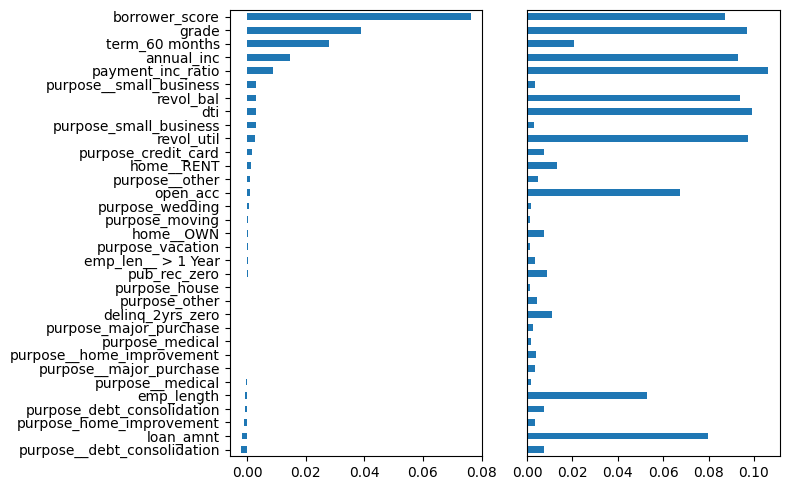

In [23]:
# Gambar 6-9: kepentingan variabel (penurunan akurasi vs penurunan Gini)
df_imp = pd.DataFrame({
    'feature': X.columns,
    'Accuracy decrease': [np.mean(scores[column]) for column in X.columns],
    'Gini decrease': rf_all.feature_importances_,
    'Entropy decrease': rf_all_entropy.feature_importances_,
})
df_imp = df_imp.sort_values('Accuracy decrease')

fig, axes = plt.subplots(ncols=2, figsize=(8, 5))
ax = df_imp.plot(kind='barh', x='feature', y='Accuracy decrease', legend=False, ax=axes[0])
ax.set_ylabel('')

ax = df_imp.plot(kind='barh', x='feature', y='Gini decrease', legend=False, ax=axes[1])
ax.set_ylabel('')
ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

**Interpretasi:** kedua ukuran **tidak sepenuhnya sepakat**. Menurut **penurunan akurasi**, `borrower_score` paling penting dengan selisih besar (≈ 0,077), diikuti `term_60 months` (≈ 0,033), `grade` (≈ 0,032), `annual_inc`, dan `payment_inc_ratio`; sebagian besar variabel lain nyaris tidak memengaruhi akurasi. Menurut **penurunan Gini**, bobot justru tersebar pada variabel numerik kontinu seperti `payment_inc_ratio`, `revol_util`, `revol_bal`, dan `borrower_score`. Variabel kontinu punya banyak titik split sehingga impurity-nya cenderung terlihat besar. Karena itu ukuran berbasis akurasi (permutasi) umumnya lebih dapat diandalkan untuk menilai pengaruh nyata terhadap prediksi.

### Hiperparameter
Random forest relatif **tahan banting** terhadap hiperparameter. Yang paling berpengaruh: `max_features` (default $\sqrt{p}$ untuk klasifikasi), `min_samples_leaf` (ukuran daun minimum, mengatur kehalusan), dan `max_depth`. Pilih lewat validasi silang atau OOB.

### Key Ideas
- **Ensemble** menggabungkan banyak model; **bagging** memakai sampel bootstrap.
- **Random forest** = bagging pohon + **subset acak prediktor** di tiap split.
- Memberi akurasi tinggi dengan penyetelan minimal, dan **OOB** memberi estimasi galat gratis.
- **Variable importance** mengidentifikasi prediktor berpengaruh (penurunan akurasi atau Gini).

---
## 4. Boosting

**Boosting** juga membuat ensemble, tetapi **berurutan (sekuensial)**: tiap model baru **berfokus pada kesalahan model sebelumnya**. Bila bagging bertujuan menurunkan variansi, boosting terutama menurunkan **bias**.

| Istilah | Penjelasan |
|---|---|
| **Boosting** | Rangkaian model, tiap model baru **memberi bobot lebih** pada rekaman yang salah diprediksi sebelumnya |
| **AdaBoost** | Boosting awal: bobot rekaman diperbarui di tiap iterasi |
| **Gradient boosting** | Boosting yang memodelkan **residual/gradien** fungsi loss |
| **Stochastic gradient boosting** | Gradient boosting dengan **sampling acak** rekaman/fitur di tiap iterasi |
| **Regularization** | Menambah **penalti** pada kompleksitas model agar tidak overfit |
| **Hyperparameters** | Parameter yang harus ditetapkan sebelum pelatihan |

### Algoritma Boosting (AdaBoost)
1. Mulai dengan bobot sama untuk semua rekaman.
2. Latih model lemah (mis. pohon dangkal) dengan bobot itu.
3. Hitung **galat terbobot** $e_m$ dan **bobot model** $\alpha_m = \tfrac{1}{2}\ln\frac{1 - e_m}{e_m}$.
4. **Naikkan bobot** rekaman yang salah diprediksi; turunkan yang benar.
5. Ulangi $M$ kali; prediksi akhir = **voting berbobot** $\alpha_m$.

### Gradient Boosting
Pada gradient boosting, tiap model baru dipasang pada **residual (gradien negatif loss)** dari ensemble saat ini, lalu ditambahkan dengan **laju pembelajaran (*learning rate*, $\eta$)**:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

$\eta$ kecil membuat pembelajaran **lebih lambat tetapi lebih stabil** (biasanya perlu lebih banyak pohon).

### XGBoost
**XGBoost** adalah implementasi gradient boosting yang **cepat, skalabel, dan teregularisasi**, dan merupakan pilihan umum pada data tabular. Hiperparameter penting:
- `n_estimators`: jumlah pohon (iterasi).
- `learning_rate` ($\eta$): kontribusi tiap pohon.
- `max_depth`: kedalaman tiap pohon (pohon dangkal = model lemah).
- `subsample`: proporsi rekaman yang dipakai tiap iterasi (stochastic).
- `colsample_bytree`: proporsi fitur tiap pohon.
- `reg_lambda`, `reg_alpha`: penalti **regularisasi L2** dan **L1** pada bobot daun.

### Contoh: XGBoost pada loan3000

In [24]:
loan3000 = pd.read_csv(LOAN3000_CSV)
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = pd.Series([1 if o == 'default' else 0 for o in loan3000[outcome]])

xgb = XGBClassifier(objective='binary:logistic', subsample=.63, eval_metric='error')
xgb.fit(X, y)

xgb_df = X.copy()
xgb_df['prediction'] = ['default' if p == 1 else 'paid off' for p in xgb.predict(X)]
xgb_df['prob_default'] = xgb.predict_proba(X)[:, 1]
print(xgb_df.head())

   borrower_score  payment_inc_ratio prediction  prob_default
0            0.40            5.11135   paid off      0.332898
1            0.40            5.43165    default      0.688950
2            0.70            9.23003    default      0.715266
3            0.40            2.33482   paid off      0.246125
4            0.45           12.10320    default      0.951596


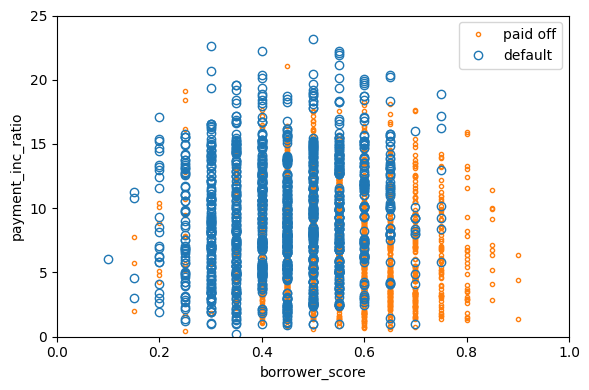

In [25]:
# Gambar 6-10: prediksi XGBoost pada ruang (borrower_score, payment_inc_ratio)
fig, ax = plt.subplots(figsize=(6, 4))

xgb_df.loc[xgb_df.prediction == 'paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.',
    markerfacecolor='none', markeredgecolor='C1', ax=ax)
xgb_df.loc[xgb_df.prediction == 'default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o',
    markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default'])
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score')
ax.set_ylabel('payment_inc_ratio')

plt.tight_layout()
plt.show()

**Interpretasi:** seperti random forest, batas keputusan XGBoost **tidak beraturan**, mengikuti pola data latih. Karena sangat fleksibel, kinerja pada data latih tidak mencerminkan kinerja sesungguhnya, sehingga regularisasi dan validasi sangat penting.

> **Catatan:** pada kode resmi buku, kolom `prob_default` diambil dari `predict_proba(X)[:, 0]`, padahal dengan label 1 = *default* kolom 0 adalah probabilitas *paid off*. Di notebook ini dipakai `[:, 1]` sehingga `prob_default` memang probabilitas *default*.

### Regularisasi: Menghindari Overfitting
Boosting yang dibiarkan terus menambah pohon akan **overfit**: galat latih terus turun, tetapi galat validasi mulai naik. XGBoost menyediakan **regularisasi** lewat penalti `reg_lambda`/`reg_alpha`, learning rate kecil, `subsample`, dan kedalaman terbatas. Berikut perbandingan model **default** (tanpa penalti) dan model **teregularisasi** pada `loan_data` lengkap.

In [26]:
predictors = ['loan_amnt', 'term', 'annual_inc', 'dti',
              'payment_inc_ratio', 'revol_bal', 'revol_util',
              'purpose', 'delinq_2yrs_zero', 'pub_rec_zero',
              'open_acc', 'grade', 'emp_length', 'purpose_',
              'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'

X = pd.get_dummies(loan_data[predictors], drop_first=True, dtype=int)
y = pd.Series([1 if o == 'default' else 0 for o in loan_data[outcome]])

train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=10000, random_state=1)

xgb_default = XGBClassifier(objective='binary:logistic', n_estimators=250, max_depth=6,
                            reg_lambda=0, learning_rate=0.3, subsample=1,
                            eval_metric='error')
xgb_default.fit(train_X, train_y)

xgb_penalty = XGBClassifier(objective='binary:logistic', n_estimators=250, max_depth=6,
                            reg_lambda=1000, learning_rate=0.1, subsample=0.63,
                            eval_metric='error')
xgb_penalty.fit(train_X, train_y)

pred_default = xgb_default.predict_proba(train_X)[:, 1]
print('default (latih)    :', np.mean(abs(train_y - pred_default) > 0.5))

pred_default = xgb_default.predict_proba(valid_X)[:, 1]
print('default (validasi) :', np.mean(abs(valid_y - pred_default) > 0.5))

pred_penalty = xgb_penalty.predict_proba(valid_X)[:, 1]
print('penalti (validasi) :', np.mean(abs(valid_y - pred_penalty) > 0.5))

default (latih)    : 0.1055401505291155
default (validasi) : 0.3611
penalti (validasi) : 0.3331


**Interpretasi:** model **default** memiliki galat latih hanya ≈ 10,6% tetapi galat validasi ≈ 36,1% (**overfitting**: selisih sekitar 25 poin). Model **teregularisasi** memiliki galat validasi lebih rendah, ≈ 33,3%, yang berarti generalisasi lebih baik. Berikut kurva galat terhadap jumlah iterasi.

   iterations  default train  penalty train  default test  penalty test
0           1       0.343755       0.354309        0.3484        0.3549
1           2       0.332947       0.345227        0.3437        0.3431
2           3       0.328816       0.340671        0.3393        0.3439
3           4       0.325194       0.341690        0.3370        0.3410
4           5       0.320752       0.336285        0.3393        0.3378


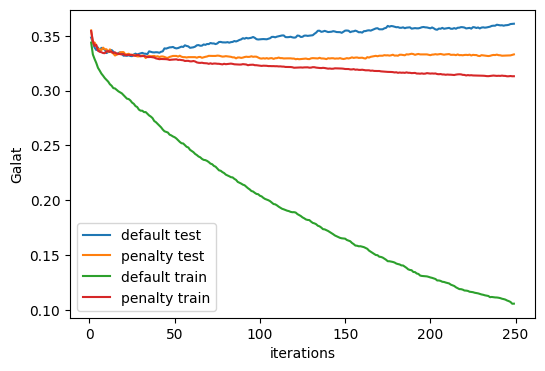

In [27]:
# Galat latih/validasi vs jumlah pohon (iterasi). iteration_range=(0, k) memakai k pohon pertama
results = []
for ntree_limit in range(1, 250):
    iteration_range = (0, ntree_limit)
    train_default = xgb_default.predict_proba(train_X, iteration_range=iteration_range)[:, 1]
    train_penalty = xgb_penalty.predict_proba(train_X, iteration_range=iteration_range)[:, 1]
    pred_default = xgb_default.predict_proba(valid_X, iteration_range=iteration_range)[:, 1]
    pred_penalty = xgb_penalty.predict_proba(valid_X, iteration_range=iteration_range)[:, 1]
    results.append({
        'iterations': ntree_limit,
        'default train': np.mean(abs(train_y - train_default) > 0.5),
        'penalty train': np.mean(abs(train_y - train_penalty) > 0.5),
        'default test': np.mean(abs(valid_y - pred_default) > 0.5),
        'penalty test': np.mean(abs(valid_y - pred_penalty) > 0.5),
    })

results = pd.DataFrame(results)
print(results.head())

ax = results.plot(x='iterations', y='default test', figsize=(6, 4))
results.plot(x='iterations', y='penalty test', ax=ax)
results.plot(x='iterations', y='default train', ax=ax)
results.plot(x='iterations', y='penalty train', ax=ax)
ax.set_ylabel('Galat')
plt.show()

**Interpretasi:** pada model **default**, galat **latih** terus menurun (menuju ≈ 10%) sementara galat **validasi** berhenti membaik sejak sekitar iterasi ke-10 lalu cenderung naik: tanda khas overfitting. Pada model **teregularisasi**, galat latih turun jauh lebih lambat (tetap ≈ 31%) dan galat validasi tetap lebih rendah dan stabil. (Catatan: buku memakai `iteration_range=[1, k+1]` yang melewatkan pohon pertama; di sini dipakai `(0, k)` yang memakai `k` pohon pertama.)

### Hiperparameter dan Validasi Silang
Hiperparameter boosting (mis. `learning_rate` $\eta$ dan `max_depth`) saling berinteraksi, sehingga dicari lewat **validasi silang** (*K-fold*): bagi data menjadi $K$ lipatan; latih pada $K-1$, validasi pada sisanya, lalu rata-ratakan galat. Berikut pencarian grid $3 \times 3$ untuk `learning_rate` dan `max_depth` dengan 5 lipatan.

In [28]:
np.random.seed(1)
idx = np.random.choice(range(5), size=len(X), replace=True)       # penetapan lipatan acak 0..4
error = []
for eta, max_depth in product([0.1, 0.5, 0.9], [3, 6, 9]):
    xgb = XGBClassifier(objective='binary:logistic', n_estimators=250,
                        max_depth=max_depth, learning_rate=eta, eval_metric='error')
    cv_error = []
    for k in range(5):
        fold_idx = idx == k
        train_X_k = X.loc[~fold_idx]; train_y_k = y[~fold_idx]
        valid_X_k = X.loc[fold_idx]; valid_y_k = y[fold_idx]

        xgb.fit(train_X_k, train_y_k)
        pred = xgb.predict_proba(valid_X_k)[:, 1]
        cv_error.append(np.mean(abs(valid_y_k - pred) > 0.5))
    error.append({'eta': eta, 'max_depth': max_depth, 'avg_error': np.mean(cv_error)})
    print(error[-1])

errors = pd.DataFrame(error)
print('\nGalat rata-rata CV (%), baris = eta, kolom = max_depth:')
print(errors.pivot_table(index='eta', columns='max_depth', values='avg_error') * 100)

{'eta': 0.1, 'max_depth': 3, 'avg_error': np.float64(0.32763534410706074)}
{'eta': 0.1, 'max_depth': 6, 'avg_error': np.float64(0.33802763403824565)}
{'eta': 0.1, 'max_depth': 9, 'avg_error': np.float64(0.3460295504436688)}
{'eta': 0.5, 'max_depth': 3, 'avg_error': np.float64(0.341132477381365)}
{'eta': 0.5, 'max_depth': 6, 'avg_error': np.float64(0.3698900014913674)}
{'eta': 0.5, 'max_depth': 9, 'avg_error': np.float64(0.37238274838814334)}
{'eta': 0.9, 'max_depth': 3, 'avg_error': np.float64(0.3533284035713775)}
{'eta': 0.9, 'max_depth': 6, 'avg_error': np.float64(0.3858040179919801)}
{'eta': 0.9, 'max_depth': 9, 'avg_error': np.float64(0.38226591098342266)}

Galat rata-rata CV (%), baris = eta, kolom = max_depth:
max_depth          3          6          9
eta                                       
0.1        32.763534  33.802763  34.602955
0.5        34.113248  36.989000  37.238275
0.9        35.332840  38.580402  38.226591


**Interpretasi:** galat terendah (≈ **32,8%**) dicapai pada **`learning_rate` = 0,1** dan **`max_depth` = 3** (kombinasi paling konservatif). Galat naik seiring `learning_rate` dan kedalaman pohon, hingga ≈ 38,6% pada `learning_rate` = 0,9 dan `max_depth` = 6, karena model makin **overfit**. Hal ini menegaskan bahwa boosting lebih baik dengan **banyak pohon kecil dan langkah kecil**.

### Perbandingan singkat: bagging vs boosting
| Aspek | Random Forest (bagging) | Boosting (XGBoost) |
|---|---|---|
| Pelatihan | Paralel, pohon **independen** | Sekuensial, tiap pohon **memperbaiki** sebelumnya |
| Tujuan utama | Menurunkan **variansi** | Menurunkan **bias** (dan variansi lewat regularisasi) |
| Pohon | Dalam (kompleks) | Dangkal (lemah) |
| Risiko overfit | Rendah (tambah pohon aman) | Lebih tinggi; perlu **regularisasi** dan *early stopping* |
| Penyetelan | Sedikit | **Banyak** hiperparameter |
| Akurasi | Sangat baik | Sering **terbaik** pada data tabular bila disetel |

### Key Ideas
- **Boosting** adalah keluarga ensemble yang melatih model **secara berurutan**, tiap model **menebus kesalahan** sebelumnya.
- **Gradient boosting** memodelkan residual; **XGBoost** adalah implementasi populer yang **cepat dan teregularisasi**.
- Tanpa kendali, boosting **overfit**; gunakan **regularisasi**, learning rate kecil, dan **validasi silang** untuk memilih hiperparameter.

---
## 5. Ringkasan Bab

Machine learning statistik menggeser fokus dari **model terstruktur** ke **prediksi berbasis data**. **KNN** mengklasifikasi berdasarkan kemiripan; **pohon keputusan** memberi aturan yang mudah dibaca; **random forest** (bagging) dan **boosting** menggabungkan banyak pohon untuk akurasi tinggi. Semuanya memerlukan **validasi** yang disiplin karena sangat fleksibel dan mudah overfit.

| Subbab | Konsep utama | Fungsi/Metode Python |
|---|---|---|
| KNN | Jarak, standardisasi, pilihan K, feature engine | `KNeighborsClassifier`, `StandardScaler`, `.kneighbors()` |
| Model pohon | Partisi rekursif, impurity (Gini/entropi), stop/pruning | `DecisionTreeClassifier`, `plot_tree`, `export_text`, `DecisionTreeRegressor` |
| Bagging & random forest | Bootstrap, OOB, subset acak prediktor, variable importance | `RandomForestClassifier(oob_score=True)`, `.feature_importances_` |
| Boosting | Gradient boosting, XGBoost, regularisasi, validasi silang | `XGBClassifier`, `reg_lambda`, `learning_rate`, `iteration_range` |

### Pelajaran Penting
1. **Standardisasi** penting untuk KNN; pilih **K** lewat validasi silang.
2. **Pohon tunggal** mudah ditafsirkan tetapi tidak stabil dan mudah overfit.
3. **Random forest** menurunkan variansi lewat rata-rata banyak pohon yang beragam; **OOB** memberi estimasi galat gratis.
4. **Boosting** sering paling akurat, tetapi menuntut **regularisasi** dan **penyetelan hiperparameter** dengan validasi silang.
5. Akurasi pada data latih **menyesatkan**; selalu evaluasi pada data validasi/OOB.
6. **Variable importance** membantu menafsirkan model kotak hitam, tetapi hati-hati terhadap bias pada ukuran berbasis impurity.

---
**Referensi:** Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical Statistics for Data Scientists* (2nd ed.). O'Reilly Media. Kode & data: <https://github.com/gedeck/practical-statistics-for-data-scientists>